# import needed python libraries like pandas,matplotlib,seaborn
# load the csv file into data frame usng read_csv

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

titanic_data = pd.read_csv("Titanic.csv")


# get the data types of dataframe

In [51]:
titanic_data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

# Inspect the data. check the first two rows and use transpose to show more information

In [13]:
titanic_data.head(2).T

,0,1
PassengerId,1,2
Survived,0,1
Pclass,3,1
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th..."
Sex,male,female
Age,22.0,38.0
SibSp,1,1
Parch,0,0
Ticket,A/5 21171,PC 17599
Fare,7.25,71.2833


# get the shape of the data frames number of rows and columns

In [14]:
titanic_data.shape

(891, 12)

In [15]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Visualise missing values using seaborn heatmap

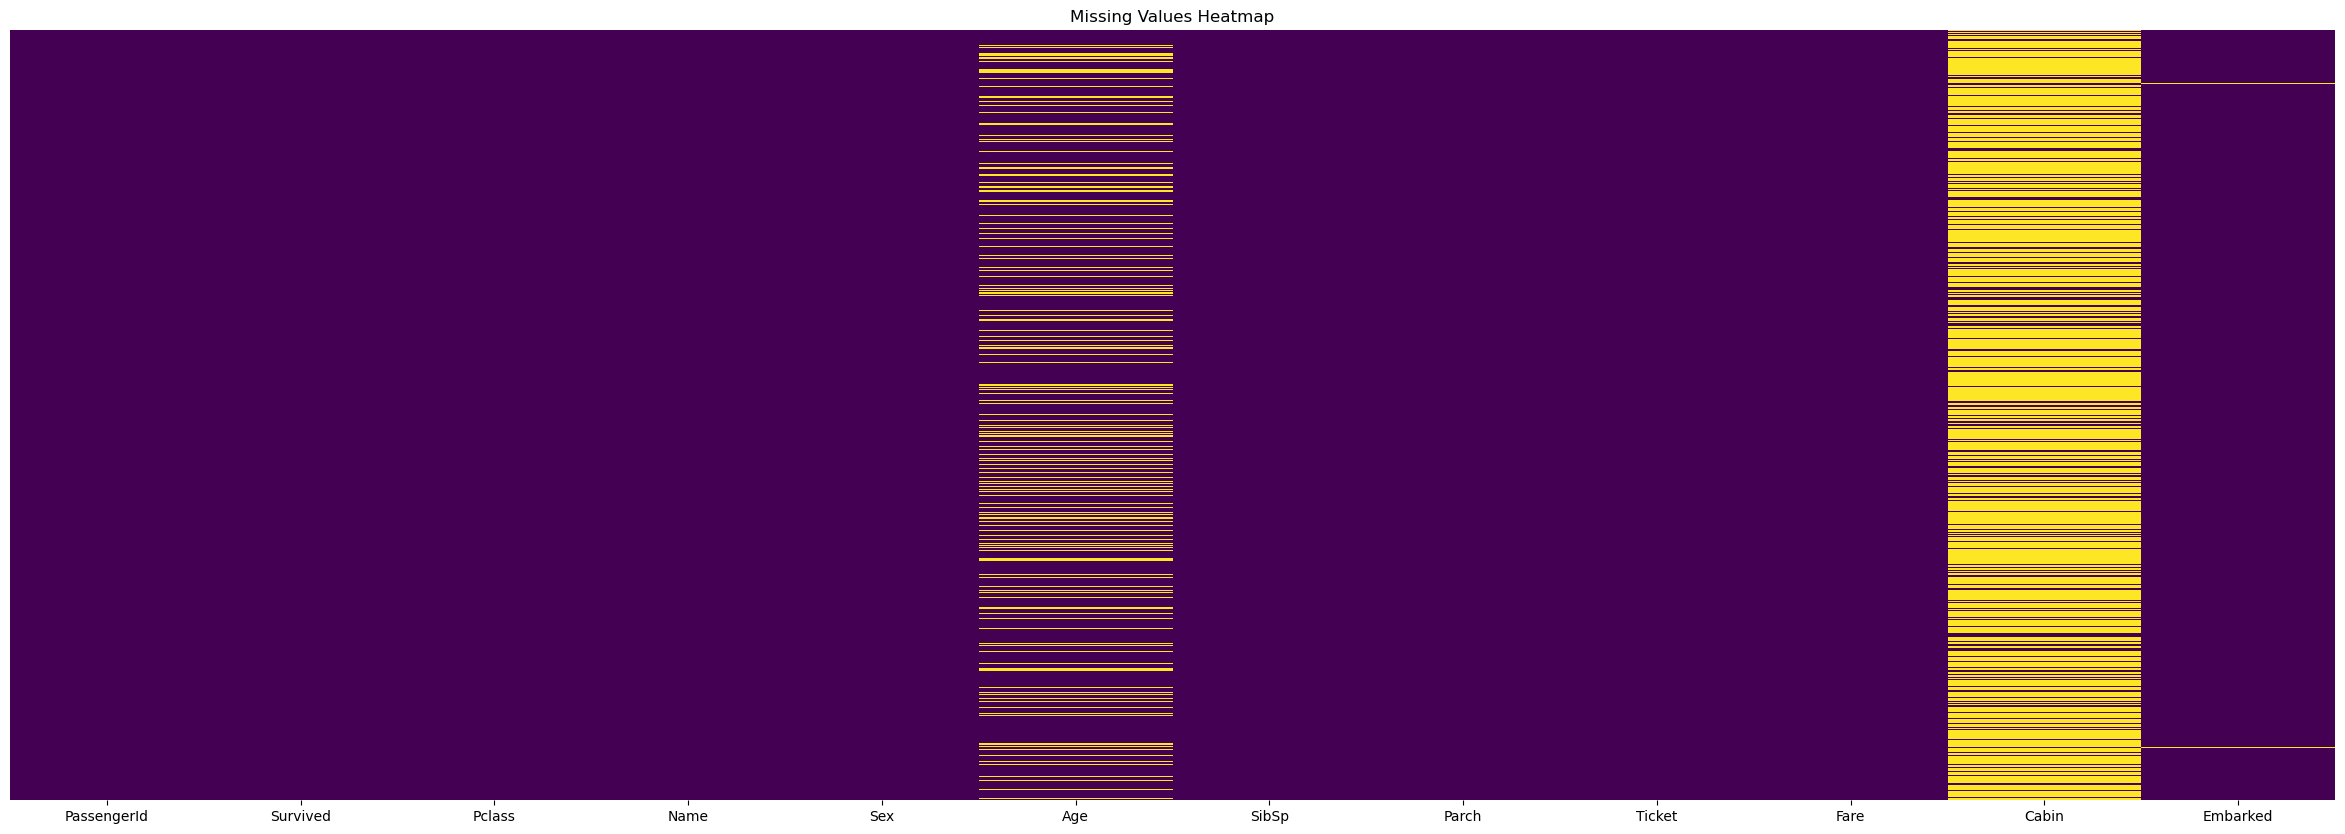

In [16]:
plt.figure(figsize=(30, 10))  # Set the figure size
sns.heatmap(titanic_data.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")  # Add a title to the plot
plt.show()

# This bar char shows survived rate by Pessengers class
# calculate test using group by pclass and get the mean of survivied 
# create a bar chart using test.plot.bar() function

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


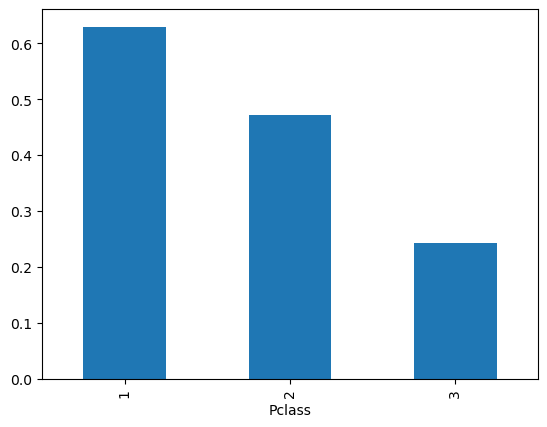

In [17]:
test = titanic_data.groupby("Pclass")["Survived"].mean()
plot_month = test.plot.bar()
print(titanic_data.groupby("Pclass")["Survived"].mean())


# This bar char shows survived rate by Sex
# calculate test using group by Sex and get the mean of survivied 
# create a bar chart using test.plot.bar() function

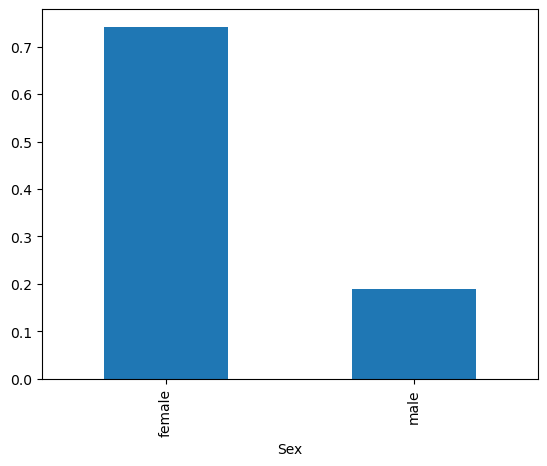

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [37]:
test= titanic_data.groupby("Sex")["Survived"].mean()
test.plot.bar()
plt.show()
print(titanic_data.groupby("Sex")["Survived"].mean())

# This bar char shows survived rate by Age_group
# calculate age_group using cut function creating two beans on age called child and Adult 
# create a bar chart using test.plot.bar() function

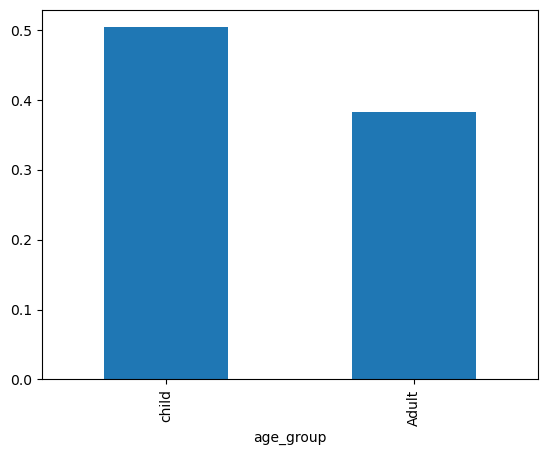

age_group
child    0.503597
Adult    0.382609
Name: Survived, dtype: float64


In [54]:
titanic_data["age_group"] = pd.cut(titanic_data["Age"], bins=[0,18, 100], labels=["child","Adult"])
test= titanic_data.groupby("age_group")["Survived"].mean()
test.plot.bar()
plt.show()
print(titanic_data.groupby("age_group")["Survived"].mean())

# This combined bar char shows survived rate by Sex, Pclass aand Age Group
# calculate test using group by Sex , age_group and Pclass get the mean of survivied 
# create a combined bar chart using test.plot.bar() function

<Axes: >

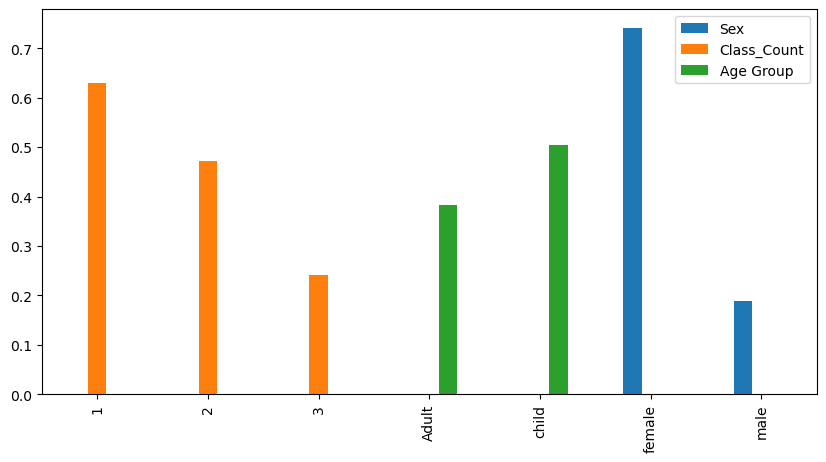

In [55]:
sex_count = titanic_data.groupby("Sex")["Survived"].mean()
class_count = titanic_data.groupby("Pclass")["Survived"].mean()
Age_group_count = titanic_data.groupby("age_group")["Survived"].mean()
combined = pd.DataFrame({"Sex": sex_count ,
                         "Class_Count":class_count,
                          "Age Group": Age_group_count
                         })
combined.plot.bar(figsize=(10,5))



# get the count of pessangers grouping by Pclass,Sex, age_group,Survived

In [60]:
titanic_data.groupby(["Pclass","Sex","age_group","Survived"])["PassengerId"].count()


Pclass  Sex     age_group  Survived
1       female  child      0             1
                           1            10
                Adult      0             2
                           1            72
        male    child      0             1
                           1             4
                Adult      0            60
                           1            36
2       female  child      1            14
                Adult      0             6
                           1            54
        male    child      0             6
                           1             9
                Adult      0            78
                           1             6
3       female  child      0            21
                           1            22
                Adult      0            34
                           1            25
        male    child      0            40
                           1            11
                Adult      0           175
                  

# get pivote tableto display pclass , sex , age_group and Survived

In [57]:

servival_count_table = titanic_data.pivot_table(values="Survived", index=["Pclass","Sex","age_group",], aggfunc="sum")
print(servival_count_table)

                         Survived
Pclass Sex    age_group          
1      female child            10
              Adult            72
       male   child             4
              Adult            36
2      female child            14
              Adult            54
       male   child             9
              Adult             6
3      female child            22
              Adult            25
       male   child            11
              Adult            27


In [42]:
titanic_data.groupby("age_group")["Survived"].mean()

age_group
child    0.503597
Adult    0.382609
Name: Survived, dtype: float64

# What is the most important factor in determining whether a person was likely to survive the sinking of the Titanic?
# insights
# Sex was the important factor to detemine whether person was likely to servive of the titanic
# second factor was age 
# third factor was class

# Using category plot to show Pclass, Sex, age_group by Survived

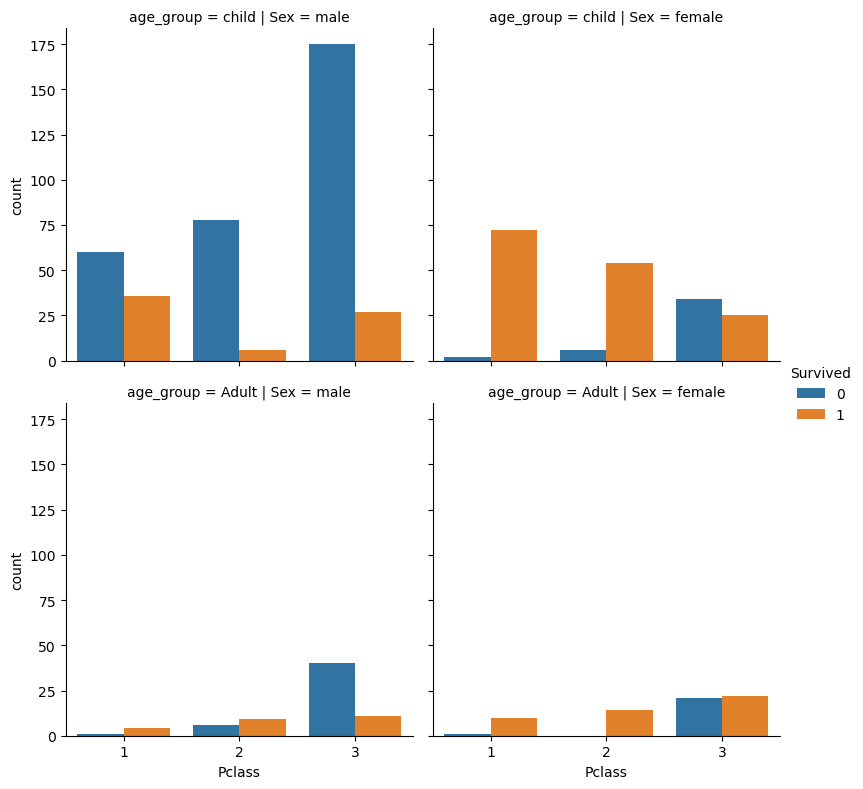

In [58]:
sns.catplot(data=titanic_data , x="Pclass", hue="Survived", col="Sex" , row="age_group", kind="count",
           height=4, aspect=1)
plt.show()

# In the movie, the upper-class passengers were given preference on lifeboats.Does this show in the data?
# Insights
# First class passangers has highest survival rates
# second class passangers has moderate survival rate
# Third class passangers has lowest survival rates

# Using count plot to show Pclass by Survived

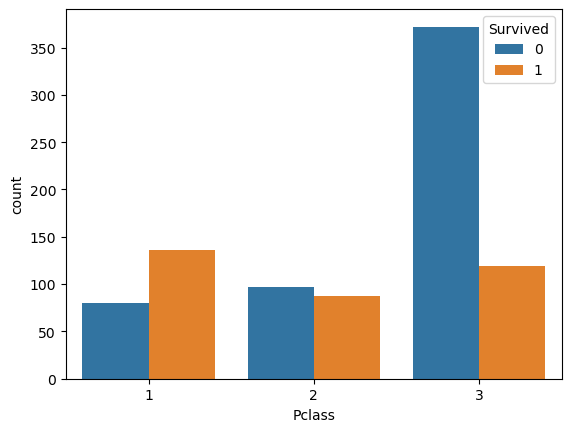

In [61]:

sns.countplot(x="Pclass", hue="Survived", data=titanic_data)
plt.show()

# “Women and children first”. Was this the case?
# Insights:
# following cat plot shows Females and childeren have more survival rate.
# Adult male passangers experienced the highest death rates.


In [62]:
print(titanic_data["age_group"].head())
titanic_data.groupby(['Sex','age_group'])["Survived"].sum()

0    Adult
1    Adult
2    Adult
3    Adult
4    Adult
Name: age_group, dtype: category
Categories (2, str): ['child' < 'Adult']


Sex     age_group
female  child         46
        Adult        151
male    child         24
        Adult         69
Name: Survived, dtype: int64

# Using category plot to show Sex, age_group by Survived

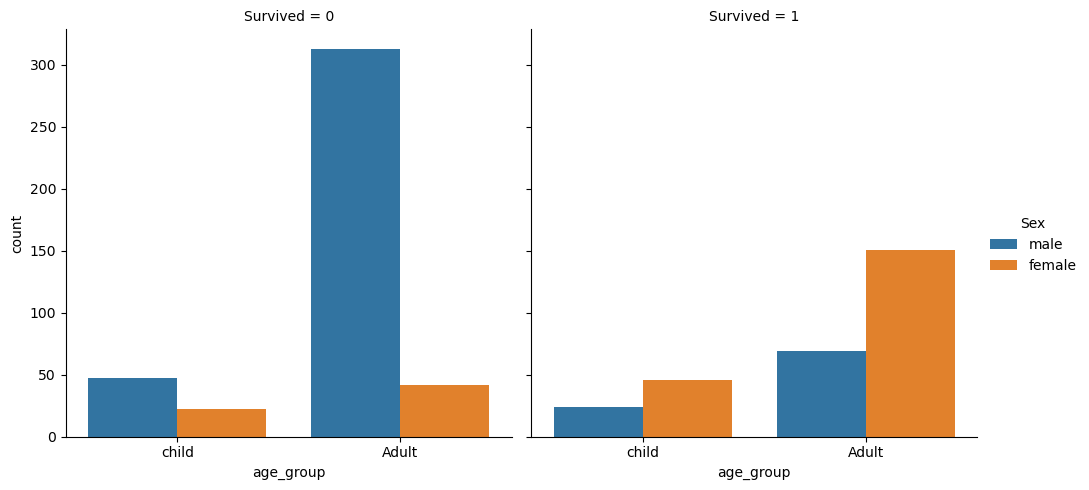

In [59]:

sns.catplot(x="age_group", hue="Sex", col="Survived" ,data=titanic_data, kind="count")
plt.show()

#

# Add one other observation that you have noted in the dataset


# Insights:
# Passanger alone has lower servival chance
# Small families with 2-4 members has better survival chance

# Using count plot to show alone by Survived

<Axes: xlabel='alone', ylabel='count'>

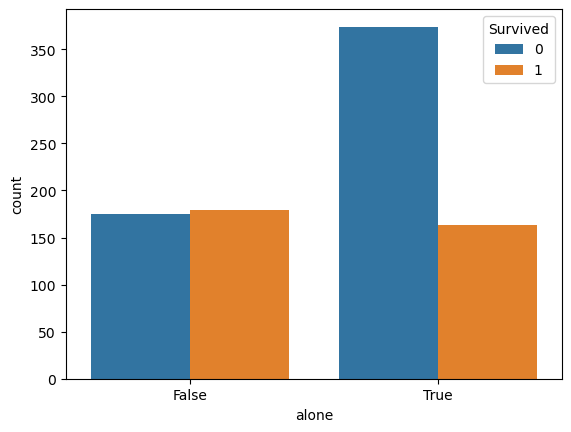

In [46]:
titanic_data["family-size"] = titanic_data["SibSp"] + titanic_data["Parch"] +1
titanic_data["alone"] = (titanic_data["family-size"]  == 1)
sns.countplot(x='alone' ,hue= 'Survived', data=titanic_data )

# Using bar plot to show family by Survived

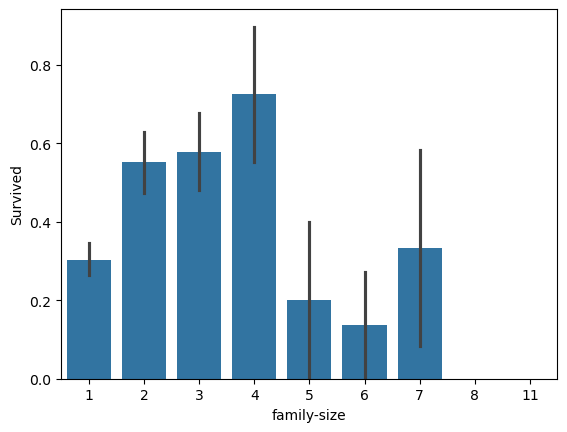

In [47]:
sns.barplot(x='family-size' , y='Survived', data=titanic_data)
plt.show()

# Paiplot provides represenation of distibution of a single variable and relatioship between other variables
# Survived, Age, Sex, Pclass, family-size

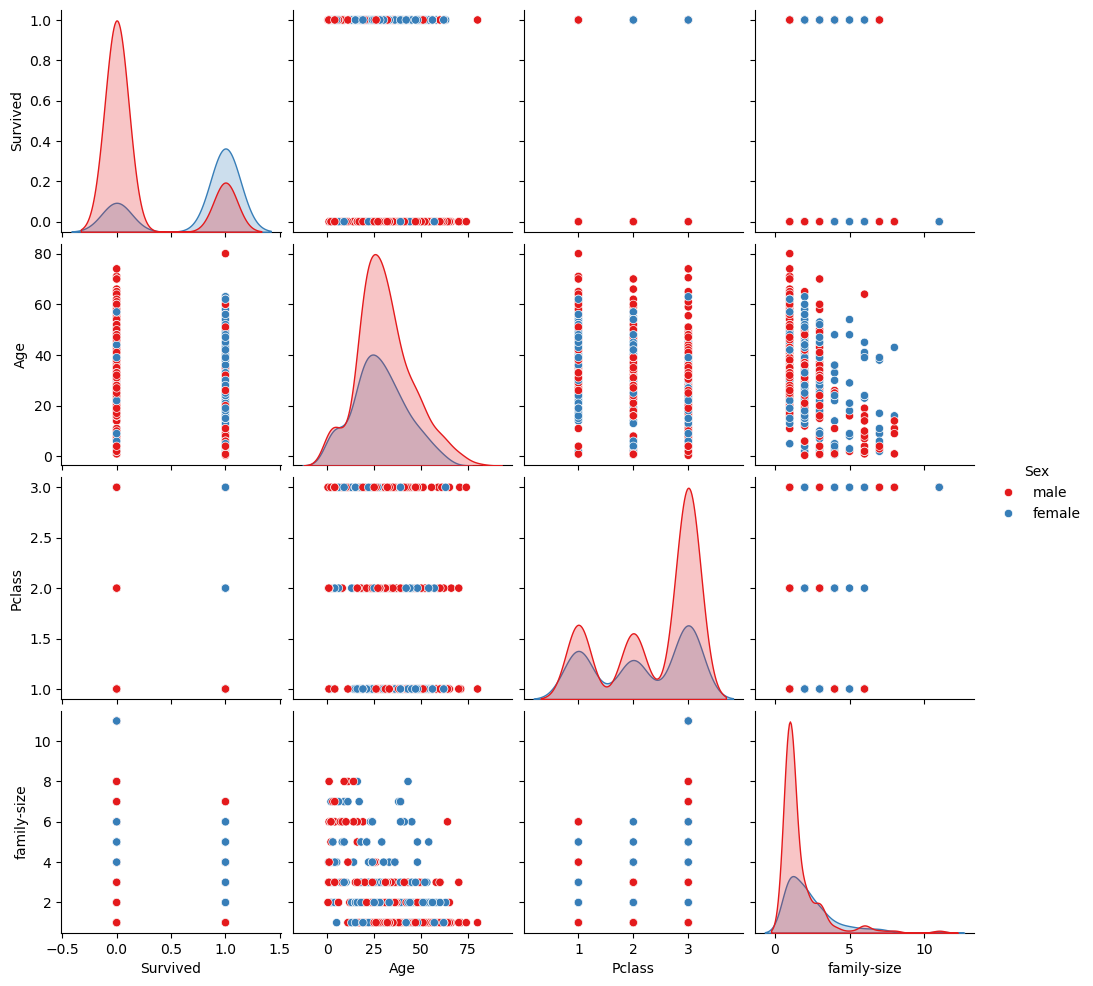

In [48]:
pair_titanic_data = titanic_data[["Survived","Age","Sex", "Pclass","family-size"]]
sns.pairplot(pair_titanic_data, hue="Sex", palette="Set1")


# Using histplot to show Fair by Survived

<Axes: xlabel='Fare', ylabel='Count'>

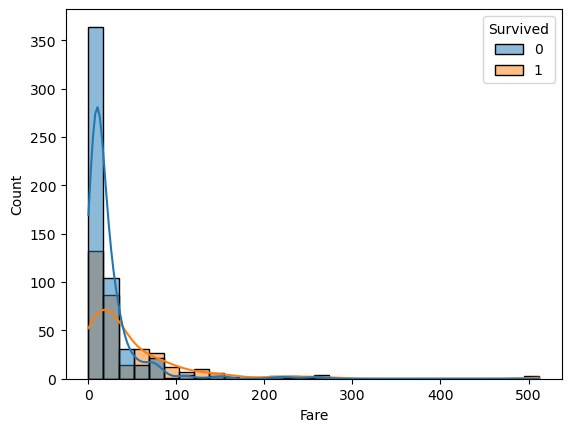

In [49]:
sns.histplot(data=titanic_data, x="Fare", hue="Survived", bins=30, kde=True )